In [18]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import ROOT

OUTPUT_DIR = Path("outputs/fixed_amp_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(phase):
    tmp = phase.split('_')
    refl = "+"
    pol = tmp[1]
    wave = "S"
    m = "0"

    if tmp[0] == 'b':
        refl = "-"

    if tmp[2] == '1':
        wave = "P"
    elif tmp[2] == '2':
        wave = "D"

    if tmp[3][0] == 'm':
        m = "-"+tmp[3][1]
    else:
        m = tmp[3][0]

    return wave + "$^" + refl + "_{\\mathrm{" + pol + "}" + m + "}$"

In [4]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

Reading 27 amplitude branches:
['a_T_0_0', 'a_T_1_1', 'a_T_1_0', 'a_T_1_m1', 'a_T_2_2', 'a_T_2_1', 'a_T_2_0', 'a_T_2_m1', 'a_T_2_m2', 'a_L_0_0', 'a_L_1_1', 'a_L_1_0', 'a_L_2_2', 'a_L_2_1', 'a_L_2_0', 'b_T_0_0', 'b_T_1_1', 'b_T_1_0', 'b_T_1_m1', 'b_T_2_2', 'b_T_2_1', 'b_T_2_0', 'b_T_2_m1', 'b_T_2_m2', 'b_L_1_1', 'b_L_2_2', 'b_L_2_1']
Min log_val = -10.700135406598742
0.005566670978103115
err_re = 0
err_im = 0
0.007422227970804154
err_re = 0
err_im = 0
0.003711113985402077
err_re = 0
err_im = 0
0.009277784963505193
err_re = 0
err_im = 0
0.007422227970804154
err_re = 0
err_im = 0
0.005566670978103115
err_re = 0
err_im = 0
0.003711113985402077
err_re = 0
err_im = 0
0.009277784963505193
err_re = 0
err_im = 0
0.005566670978103115
err_re = 0
err_im = 0
0.03154446887591766
err_re = 0
err_im = 0
0.03340002586861869
err_re = 0
err_im = 0
0.0289466890861362
err_re = 0
err_im = 0
0.030431134680297033
err_re = 0
err_im = 0
0.03525558286131973
err_re = 0
err_im = 0
0.032657803071538274
err_re = 0
er

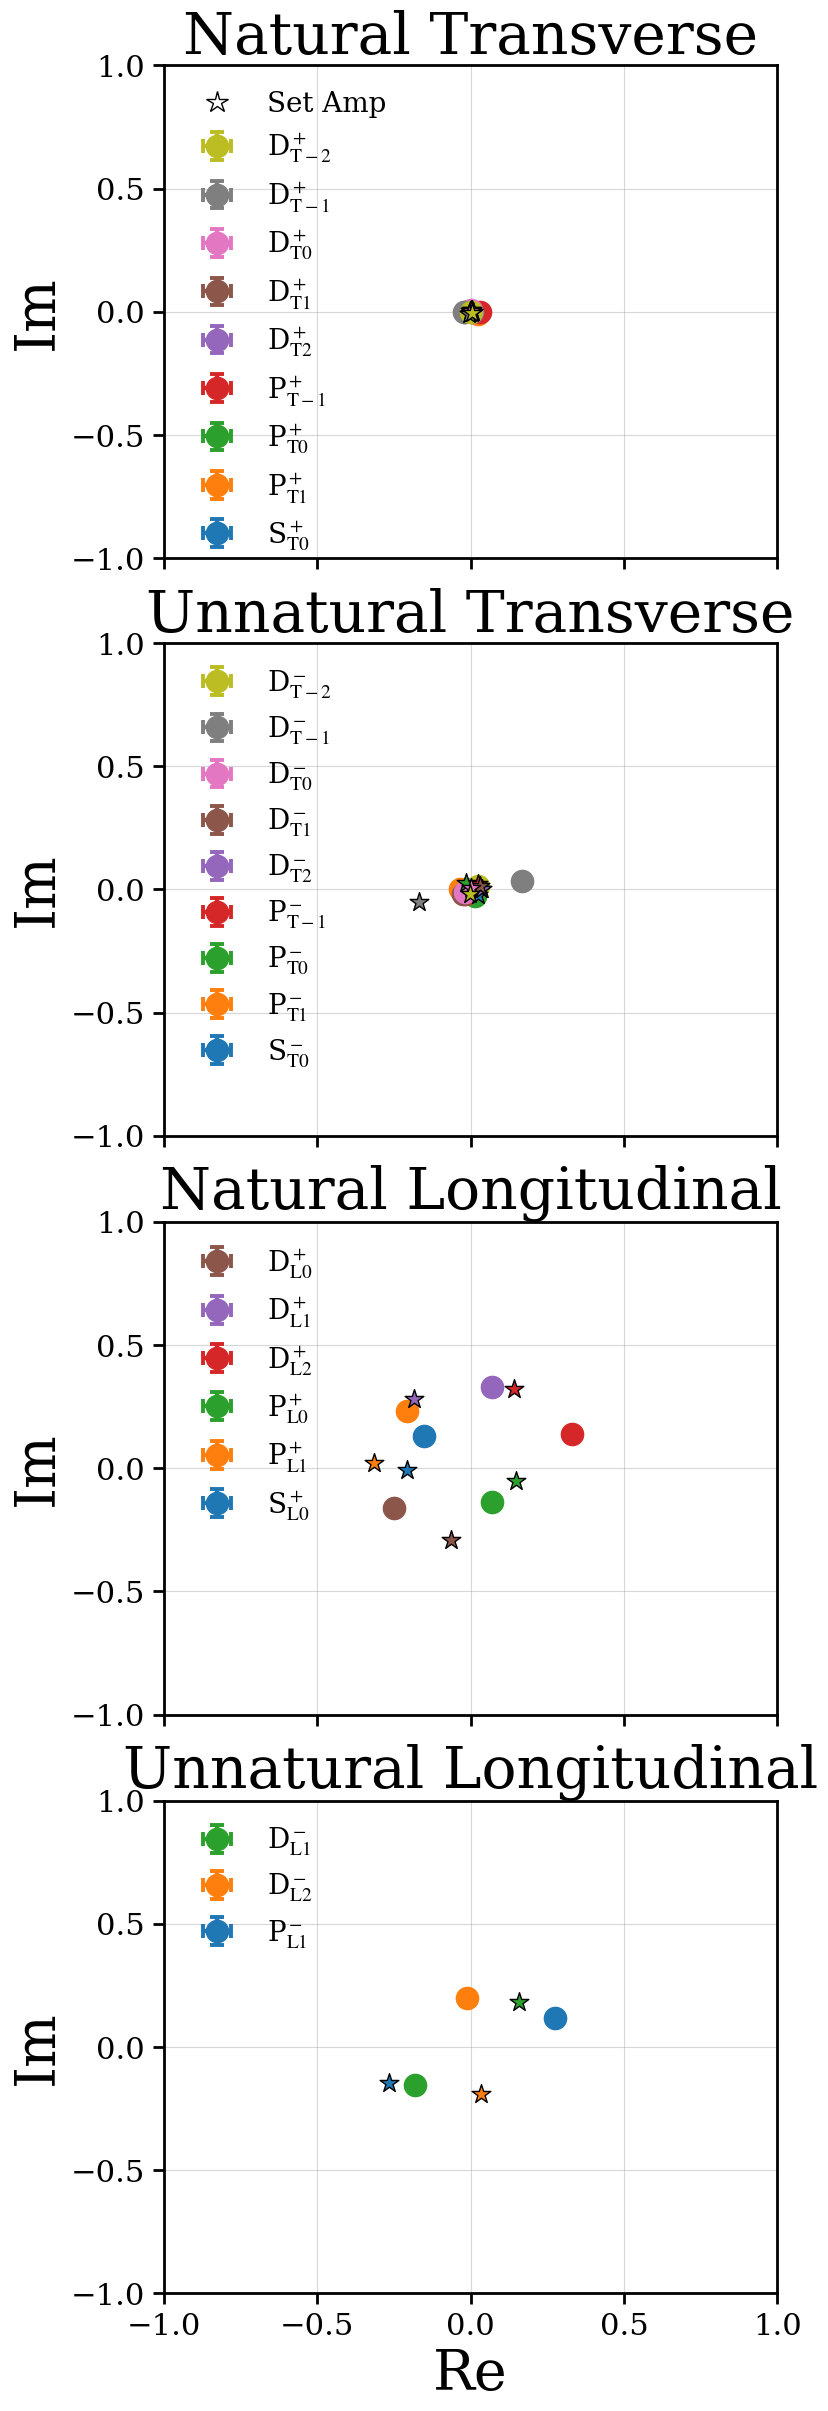

In [38]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
    "savefig.dpi": 300,
})


def apply_poster_axis_style(ax, labelsize=20):
    ax.tick_params(axis='both', which='major', labelsize=labelsize, width=2.0, length=8, pad=6)
    ax.tick_params(axis='both', which='minor', width=1.6, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)


def normalise_truth_amps(truth_amps, epsilon=0.8, target=1.0):
    """
    Normalise truth magnitudes using the same convention as the C generator:

        sum_T |A_T|^2 + epsilon * sum_L fold(m) |A_L|^2 = target,

    where longitudinal m > 0 waves receive fold(m)=2 because the negative-m
    partner is folded in by the longitudinal-parity convention.
    """
    norm2 = 0.0

    for name, (mag, phase) in truth_amps.items():
        refl, pol, ell, m = parse_amp_name(name)
        if pol == "L":
            fold_weight = 2.0 if m > 0 else 1.0
            norm2 += epsilon * fold_weight * mag**2
        else:
            norm2 += mag**2

    if norm2 <= 0.0:
        raise ValueError("Cannot normalise amplitudes: norm is zero.")

    scale = np.sqrt(target / norm2)

    return {
        name: (mag * scale, phase)
        for name, (mag, phase) in truth_amps.items()
    }


def parse_amp_name(name):
    """Return (reflectivity, polarisation, ell, m) from e.g. b_L_1_m1."""
    refl, pol, ell, m = name.split('_')
    ell = int(ell)
    m = -int(m[1:]) if m.startswith('m') else int(m)
    return refl, pol, ell, m


def phase_col_from_mag_col(name):
    """Convert a_T_1_0 -> aphi_T_1_0 and b_T_1_0 -> bphi_T_1_0."""
    if name.startswith("a_"):
        return name.replace("a_", "aphi_", 1)
    if name.startswith("b_"):
        return name.replace("b_", "bphi_", 1)
    raise ValueError(f"Unrecognised amplitude name: {name}")


def keep_amp(name):
    """Skip longitudinal waves that are no longer present in the ROOT output."""
    refl, pol, ell, m = parse_amp_name(name)

    # Do not read negative-m longitudinal waves, e.g. a_L_1_m1/b_L_1_m1.
    if pol == "L" and m < 0:
        return False

    # Negative-reflectivity longitudinal m=0 amplitudes are absent/zero.
    if refl == "b" and pol == "L" and m == 0:
        return False

    return True


# -----------------------------------------------------------------------------
# Truth datasets
# -----------------------------------------------------------------------------
# These are the fixed-amplitude points from GenerateMomentsFromFixedAmplitudes.C.
# No ROOT filenames are stored here; select one truth dataset at a time below.
# The dictionaries store: amplitude_name -> (magnitude, phase).

# Random values for closure test
truth_amps_random_closure = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.278093, -0.763191),
    "a_T_1_1":   (0.187800,  0.326981),
    "a_T_1_0":   (0.119613,  2.069711),
    "a_T_1_m1":   (0.097077,  0.744682),
    "a_T_2_2":   (0.320298,  0.000000),
    "a_T_2_1":   (0.294303,  0.486018),
    "a_T_2_0":   (0.388018,  1.285363),
    "a_T_2_m1":   (0.037811, -2.853670),
    "a_T_2_m2":   (0.183498, -1.709666),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.001290, -1.323314),
    "a_L_1_1":   (0.095088, -2.640245),
    "a_L_1_0":   (0.219784, -1.678924),
    "a_L_2_2":   (0.086477, -1.395033),
    "a_L_2_1":   (0.282641,  0.852531),
    "a_L_2_0":   (0.237000, -0.849284),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.073704,  1.223400),
    "b_T_1_1":   (0.352029, -1.464122),
    "b_T_1_0":   (0.002826,  2.743582),
    "b_T_1_m1":   (0.350459,  0.930134),
    "b_T_2_2":   (0.303627,  0.000000),
    "b_T_2_1":   (0.147978, -2.066297),
    "b_T_2_0":   (0.067619,  1.439646),
    "b_T_2_m1":   (0.416301, -2.114905),
    "b_T_2_m2":   (0.146388, -0.757404),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.040336,  1.075766),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.262566,  1.159966),
    "b_L_2_1":   (0.351028,  2.154202),
    "b_L_2_0":   (0.000000,  0.000000),

}

# Large a_T and b_L; small a_L and b_T
truth_amps_large_aT_bL = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.850000, -0.763191),
    "a_T_1_1":   (0.900000,  0.000000),
    "a_T_1_0":   (0.780000,  2.069711),
    "a_T_1_m1":   (0.820000,  0.744682),
    "a_T_2_2":   (0.950000,  0.000000),
    "a_T_2_1":   (0.880000,  0.486018),
    "a_T_2_0":   (0.920000,  1.285363),
    "a_T_2_m1":   (0.750000, -2.853670),
    "a_T_2_m2":   (0.800000, -1.709666),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.010000, -1.323314),
    "a_L_1_1":   (0.020000, -2.640245),
    "a_L_1_0":   (0.015000, -1.678924),
    "a_L_2_2":   (0.020000, -1.395033),
    "a_L_2_1":   (0.025000,  0.852531),
    "a_L_2_0":   (0.015000, -0.849284),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.015000,  1.223400),
    "b_T_1_1":   (0.020000,  0.000000),
    "b_T_1_0":   (0.010000,  2.743582),
    "b_T_1_m1":   (0.025000,  0.930134),
    "b_T_2_2":   (0.020000,  0.000000),
    "b_T_2_1":   (0.015000, -2.066297),
    "b_T_2_0":   (0.010000,  1.439646),
    "b_T_2_m1":   (0.025000, -2.114905),
    "b_T_2_m2":   (0.015000, -0.757404),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.850000,  3.075766),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.950000,  1.159966),
    "b_L_2_1":   (0.900000,  2.154202),
    "b_L_2_0":   (0.000000,  0.000000),

}

# Large b_T and a_L; small b_L and a_T
truth_amps_large_bT_aL_full = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.015000,  1.223400),
    "a_T_1_1":   (0.020000,  0.000000),
    "a_T_1_0":   (0.010000,  2.743582),
    "a_T_1_m1":   (0.025000,  0.930134),
    "a_T_2_2":   (0.020000,  0.000000),
    "a_T_2_1":   (0.015000, -2.066297),
    "a_T_2_0":   (0.010000,  1.439646),
    "a_T_2_m1":   (0.025000, -2.114905),
    "a_T_2_m2":   (0.015000, -0.757404),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.560000, -3.098700),
    "a_L_1_1":   (0.850000,  3.075766),
    "a_L_1_0":   (0.420000, -0.345900),
    "a_L_2_2":   (0.950000,  1.159966),
    "a_L_2_1":   (0.900000,  2.154202),
    "a_L_2_0":   (0.800000, -1.789620),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.850000, -0.763191),
    "b_T_1_1":   (0.900000,  0.000000),
    "b_T_1_0":   (0.780000,  2.069711),
    "b_T_1_m1":   (0.820000,  0.744682),
    "b_T_2_2":   (0.950000,  0.000000),
    "b_T_2_1":   (0.880000,  0.486018),
    "b_T_2_0":   (0.920000,  1.285363),
    "b_T_2_m1":   (0.750000, -2.853670),
    "b_T_2_m2":   (0.800000, -1.709666),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.020000, -2.640245),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.020000, -1.395033),
    "b_L_2_1":   (0.025000,  0.852531),
    "b_L_2_0":   (0.000000,  0.000000),

}

# Large b_T with moderate b_L; small a_T and a_L
truth_amps_large_bT_moderate_bL_small_a = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.015000,  1.223400),
    "a_T_1_1":   (0.020000,  0.000000),
    "a_T_1_0":   (0.010000,  2.743582),
    "a_T_1_m1":   (0.025000,  0.930134),
    "a_T_2_2":   (0.020000,  0.000000),
    "a_T_2_1":   (0.015000, -2.066297),
    "a_T_2_0":   (0.010000,  1.439646),
    "a_T_2_m1":   (0.025000, -2.114905),
    "a_T_2_m2":   (0.015000, -0.757404),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.056000, -3.098700),
    "a_L_1_1":   (0.085000,  3.075766),
    "a_L_1_0":   (0.042000, -0.345900),
    "a_L_2_2":   (0.095000,  1.159966),
    "a_L_2_1":   (0.090000,  2.154202),
    "a_L_2_0":   (0.080000, -1.789620),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.850000, -0.763191),
    "b_T_1_1":   (0.900000,  0.000000),
    "b_T_1_0":   (0.780000,  2.069711),
    "b_T_1_m1":   (0.820000,  0.744682),
    "b_T_2_2":   (0.950000,  0.000000),
    "b_T_2_1":   (0.880000,  0.486018),
    "b_T_2_0":   (0.920000,  1.285363),
    "b_T_2_m1":   (0.750000, -2.853670),
    "b_T_2_m2":   (0.800000, -1.709666),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.120000, -2.640245),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.720000, -1.395033),
    "b_L_2_1":   (0.425000,  0.852531),
    "b_L_2_0":   (0.000000,  0.000000),

}

# Small b_T with large a_L
truth_amps_small_bT_large_aL = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.150000,  1.223400),
    "a_T_1_1":   (0.200000,  0.000000),
    "a_T_1_0":   (0.310000,  2.743582),
    "a_T_1_m1":   (0.250000,  0.930134),
    "a_T_2_2":   (0.520000,  0.000000),
    "a_T_2_1":   (0.150000, -2.066297),
    "a_T_2_0":   (0.100000,  1.439646),
    "a_T_2_m1":   (0.290000, -2.114905),
    "a_T_2_m2":   (0.110000, -0.757404),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.560000, -3.098700),
    "a_L_1_1":   (0.850000,  3.075766),
    "a_L_1_0":   (0.420000, -0.345900),
    "a_L_2_2":   (0.950000,  1.159966),
    "a_L_2_1":   (0.900000,  2.154202),
    "a_L_2_0":   (0.800000, -1.789620),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.085000, -0.763191),
    "b_T_1_1":   (0.090000,  0.000000),
    "b_T_1_0":   (0.078000,  2.069711),
    "b_T_1_m1":   (0.082000,  0.744682),
    "b_T_2_2":   (0.095000,  0.000000),
    "b_T_2_1":   (0.188000,  0.486018),
    "b_T_2_0":   (0.092000,  1.285363),
    "b_T_2_m1":   (0.075000, -2.853670),
    "b_T_2_m2":   (0.080000, -1.709666),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.020000, -2.640245),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.020000, -1.395033),
    "b_L_2_1":   (0.025000,  0.852531),
    "b_L_2_0":   (0.000000,  0.000000),

}

# L/T test: large transverse components
truth_amps_large_T_mixed = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.455000,  1.223400),
    "a_T_1_1":   (0.234000,  0.000000),
    "a_T_1_0":   (0.120000,  2.743582),
    "a_T_1_m1":   (0.450000,  0.930134),
    "a_T_2_2":   (0.200000,  0.000000),
    "a_T_2_1":   (0.170000, -2.066297),
    "a_T_2_0":   (0.199000,  1.439646),
    "a_T_2_m1":   (0.670000, -2.114905),
    "a_T_2_m2":   (0.890000, -0.757404),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.056000, -3.098700),
    "a_L_1_1":   (0.085000,  3.075766),
    "a_L_1_0":   (0.042000, -0.345900),
    "a_L_2_2":   (0.095000,  1.159966),
    "a_L_2_1":   (0.090000,  2.154202),
    "a_L_2_0":   (0.080000, -1.789620),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.850000, -0.763191),
    "b_T_1_1":   (0.900000,  0.000000),
    "b_T_1_0":   (0.780000,  2.069711),
    "b_T_1_m1":   (0.820000,  0.744682),
    "b_T_2_2":   (0.950000,  0.000000),
    "b_T_2_1":   (0.880000,  0.486018),
    "b_T_2_0":   (0.920000,  1.285363),
    "b_T_2_m1":   (0.750000, -2.853670),
    "b_T_2_m2":   (0.800000, -1.709666),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.020000, -2.640245),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.020000, -1.395033),
    "b_L_2_1":   (0.025000,  0.852531),
    "b_L_2_0":   (0.000000,  0.000000),

}

# L/T test: large longitudinal components
truth_amps_large_L_mixed = {
    # Positive-reflectivity transverse
    "a_T_0_0":   (0.015000,  1.223400),
    "a_T_1_1":   (0.020000,  0.000000),
    "a_T_1_0":   (0.010000,  2.743582),
    "a_T_1_m1":   (0.025000,  0.930134),
    "a_T_2_2":   (0.020000,  0.000000),
    "a_T_2_1":   (0.015000, -2.066297),
    "a_T_2_0":   (0.010000,  1.439646),
    "a_T_2_m1":   (0.025000, -2.114905),
    "a_T_2_m2":   (0.015000, -0.757404),

    # Positive-reflectivity longitudinal
    "a_L_0_0":   (0.560000, -3.098700),
    "a_L_1_1":   (0.850000,  3.075766),
    "a_L_1_0":   (0.420000, -0.345900),
    "a_L_2_2":   (0.950000,  1.159966),
    "a_L_2_1":   (0.900000,  2.154202),
    "a_L_2_0":   (0.800000, -1.789620),

    # Negative-reflectivity transverse
    "b_T_0_0":   (0.085000, -0.763191),
    "b_T_1_1":   (0.090000,  0.000000),
    "b_T_1_0":   (0.078000,  2.069711),
    "b_T_1_m1":   (0.082000,  0.744682),
    "b_T_2_2":   (0.095000,  0.000000),
    "b_T_2_1":   (0.088000,  0.486018),
    "b_T_2_0":   (0.022000,  1.285363),
    "b_T_2_m1":   (0.475000, -2.853670),
    "b_T_2_m2":   (0.050000, -1.709666),

    # Negative-reflectivity longitudinal
    "b_L_0_0":   (0.000000,  0.000000),
    "b_L_1_1":   (0.820000, -2.640245),
    "b_L_1_0":   (0.000000,  0.000000),
    "b_L_2_2":   (0.520000, -1.395033),
    "b_L_2_1":   (0.650000,  0.852531),
    "b_L_2_0":   (0.000000,  0.000000),

}

TRUTH_DATASETS = {
    "large_norm_rand": truth_amps_random_closure,
    "large_aTbL": truth_amps_large_aT_bL,
    "large_bTaL": truth_amps_large_bT_aL_full,
    "large_b": truth_amps_large_bT_moderate_bL_small_a,
    "large_a": truth_amps_small_bT_large_aL,
    "large_T": truth_amps_large_T_mixed,
    "large_L": truth_amps_large_L_mixed,
}



# Select the active fixed-amplitude dataset.
truth_dataset_name = "large_L"


truth_amps = TRUTH_DATASETS[truth_dataset_name].copy()

# Use the same epsilon value used when generating/calculating the moments.
epsilon = 0.8
truth_amps = normalise_truth_amps(truth_amps, epsilon=epsilon, target=1.0)

# Build one self-contained table describing the ROOT branches and truth values.
wave_rows = []
for mag_col, (tru_mag, tru_phase) in truth_amps.items():
    if not keep_amp(mag_col):
        continue

    wave_rows.append({
        "mag": mag_col,
        "phase": phase_col_from_mag_col(mag_col),
        "tru_mag": tru_mag,
        "tru_phase": tru_phase,
        "group": (parse_amp_name(mag_col)[0], parse_amp_name(mag_col)[1]),
    })

# These are the only branches requested from the ROOT file.
cols_mag = [row["mag"] for row in wave_rows]
cols_phase = [row["phase"] for row in wave_rows]
cols_to_read = cols_mag + cols_phase

group_defs = [
    (("a", "T"), "Natural Transverse"),
    (("b", "T"), "Unnatural Transverse"),
    (("a", "L"), "Natural Longitudinal"),
    (("b", "L"), "Unnatural Longitudinal"),
]

print("Reading", len(cols_mag), "amplitude branches:")
print(cols_mag)

Q2 = np.array([1])
N  = 903

# For HERMES data they are saved this way (4 Q2 bins)
df = ROOT.RDataFrame(
    "fitResults",
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/fixed_"+truth_dataset_name+".root"
)

min = df.Min("log_val").GetValue()
print("Min log_val = "+str(min))
df = df.Filter("log_val<="+str(min))

arrays = df.AsNumpy(columns=cols_to_read)
arrays_mag = {name: arrays[name] for name in cols_mag}
arrays_phase = {name: arrays[name] for name in cols_phase}

fig, axs = plt.subplots(4, 1, figsize=(8, 24), sharex=True, constrained_layout=True)
set_amp_label_added = False

for j, (group_key, title) in enumerate(group_defs):
    group_rows = [row for row in wave_rows if row["group"] == group_key]

    for row in group_rows:
        mag_col = row["mag"]
        phase_col = row["phase"]

        # Fitted amplitudes from ROOT.
        mag = arrays_mag[mag_col][0]
        phase = arrays_phase[phase_col][0]

        # Fixed/truth amplitudes from the active truth dataset.
        tru_mag = row["tru_mag"]
        tru_phase = row["tru_phase"]

        print(tru_mag)
        mean_re = mag * np.cos(phase)
        mean_im = mag * np.sin(phase)

        tru_re = tru_mag * np.cos(tru_phase)
        tru_im = tru_mag * np.sin(tru_phase)

        err_re = 0 # np.sqrt(np.cos(phase)**2 * err_mag**2 + mag**2 * np.sin(phase)**2 * err_phase**2)
        err_im = 0 #np.sqrt(np.sin(phase)**2 * err_mag**2 + mag**2 * np.cos(phase)**2 * err_phase**2)

        print("err_re = "+str(err_re))
        print("err_im = "+str(err_im))

        dot = axs[j].errorbar(
            mean_re, mean_im,
            xerr=err_re, yerr=err_im,
            fmt='o', markersize=16, elinewidth=3.2,
            capsize=5, capthick=2.8,
            label=ToWave(mag_col)
        )

        clr = dot.lines[0].get_color()

        axs[j].scatter(
            tru_re, tru_im,
            zorder=5, marker="*", s=200,
            color=clr, edgecolors="black"
        )


    axs[j].axis(xmin=-1, xmax=1, ymin=-1, ymax=1)
    axs[j].set_ylabel("Im")
    if j == 3:
        axs[j].set_xlabel("Re")

    axs[j].set_title(title)
    axs[j].set_yticks([-1, -0.5, 0, 0.5, 1])
    axs[j].set_xticks([-1, -0.5, 0, 0.5, 1])
    axs[j].grid(True, alpha=0.5)
    handles, labels = axs[j].get_legend_handles_labels()
    if (not set_amp_label_added):
        star = Line2D([0], [0], label="Set Amp", marker='*', markersize=16,
             markeredgecolor='black', markerfacecolor="white", linestyle='')
        set_amp_label_added = True
        handles.append(star)
    axs[j].legend(handles=handles, loc="upper left", frameon=False, fontsize=20, reverse=True)
    apply_poster_axis_style(axs[j], labelsize=22)

fig.savefig(OUTPUT_DIR / ("fixed_"+truth_dataset_name+".pdf"), dpi=600, bbox_inches='tight', transparent=True, format='pdf')



In [ ]:
# Moments for random closure test
truth_moments_random_closure = {
    # alpha = 0
    "H_0_0_0":  1.325536027,
    "H_0_1_0": -0.05936364006,
    "H_0_1_1":  0.06042804746,
    "H_0_2_0": -0.09748574669,
    "H_0_2_1":  0.06299405531,
    "H_0_2_2":  0.0899654657,
    "H_0_3_0":  0.05096246583,
    "H_0_3_1": -0.02401051722,
    "H_0_3_2": -0.04827609209,
    "H_0_3_3": -0.03310834938,
    "H_0_4_0":  0.002794476218,
    "H_0_4_1":  0.02733630618,
    "H_0_4_2": -0.02752155767,
    "H_0_4_3":  0.01770764158,
    "H_0_4_4":  0.01184958738,

    # alpha = 1
    "H_1_0_0":  0.1008102492,
    "H_1_1_0":  0.04592250258,
    "H_1_1_1":  0.02157825646,
    "H_1_2_0":  0.1050852941,
    "H_1_2_1": -0.0229497622,
    "H_1_2_2": -0.02260625364,
    "H_1_3_0":  0.005689707034,
    "H_1_3_1":  0.01923115731,
    "H_1_3_2":  0.05555479016,
    "H_1_3_3":  0.02816146053,
    "H_1_4_0":  0.01263389179,
    "H_1_4_1":  0.03477150586,
    "H_1_4_2": -0.02720361411,
    "H_1_4_3":  0.03979176999,
    "H_1_4_4":  0.005552745267,

    # alpha = 2
    "H_2_1_1": -0.06744606998,
    "H_2_2_1": -0.04536501978,
    "H_2_2_2": -0.03677343917,
    "H_2_3_1": -0.01268059587,
    "H_2_3_2":  0.05620949246,
    "H_2_3_3": -0.01993742782,
    "H_2_4_1": -0.0364652028,
    "H_2_4_2": -0.06586764094,
    "H_2_4_3": -0.03283629409,
    "H_2_4_4":  0.000451363974,

    # alpha = 3
    "H_3_1_1": -0.07239696304,
    "H_3_2_1": -0.04445160958,
    "H_3_2_2": -0.1478619055,
    "H_3_3_1":  0.04670721307,
    "H_3_3_2":  0.04611858218,
    "H_3_3_3": -0.05471392684,
    "H_3_4_1":  0.02560017317,
    "H_3_4_2":  0.02781186391,
    "H_3_4_3":  0.03076471636,
    "H_3_4_4": -0.04352499548,

    # alpha = 4
    "H_4_0_0":  0.8430799657,
    "H_4_1_0":  0.004256831894,
    "H_4_1_1": -0.03235559627,
    "H_4_2_0":  0.05626788196,
    "H_4_2_1":  0.03699648918,
    "H_4_2_2": -0.02639576586,
    "H_4_3_0":  0.04624254626,
    "H_4_3_1": -0.04610748747,
    "H_4_3_2": -0.01639239215,
    "H_4_3_3": -0.008360155834,
    "H_4_4_0": -0.06653355568,
    "H_4_4_1": -0.01477868824,
    "H_4_4_2": -0.00811179639,
    "H_4_4_3": -0.04546697922,
    "H_4_4_4": -0.03014427936,

    # alpha = 5
    "H_5_0_0":  0.02172731838,
    "H_5_1_0":  0.1436947007,
    "H_5_1_1":  0.00511547321,
    "H_5_2_0":  0.01886074057,
    "H_5_2_1":  0.02093606838,
    "H_5_2_2": -0.0589727854,
    "H_5_3_0":  0.0299292444,
    "H_5_3_1":  0.01275744057,
    "H_5_3_2": -0.02654052489,
    "H_5_3_3":  0.01150131358,
    "H_5_4_0":  0.01889805596,
    "H_5_4_1": -0.06344372725,
    "H_5_4_2": -0.04854245569,
    "H_5_4_3": -0.04016069386,
    "H_5_4_4":  0.008656805102,

    # alpha = 6
    "H_6_1_1":  0.06023915632,
    "H_6_2_1": -0.04576118281,
    "H_6_2_2": -0.003089573967,
    "H_6_3_1": -0.02060822631,
    "H_6_3_2":  0.0474140718,
    "H_6_3_3":  0.04534082817,
    "H_6_4_1":  0.001000298709,
    "H_6_4_2":  0.006009075459,
    "H_6_4_3":  0.0330303663,
    "H_6_4_4": -0.01006715112,

    # alpha = 7
    "H_7_1_1":  0.004597020081,
    "H_7_2_1":  0.002721664274,
    "H_7_2_2": -0.001150132194,
    "H_7_3_1": -0.02824418698,
    "H_7_3_2":  0.04635508225,
    "H_7_3_3": -0.02425426468,
    "H_7_4_1": -0.03453441949,
    "H_7_4_2": -0.02915717654,
    "H_7_4_3": -0.02283634298,
    "H_7_4_4": -0.04904510384,

    # alpha = 8
    "H_8_0_0": -0.3235393137,
    "H_8_1_0": -0.005032673564,
    "H_8_1_1": -0.06279475079,
    "H_8_2_0": -0.07712072898,
    "H_8_2_1":  0.07903232252,
    "H_8_2_2":  0.06062875889,
    "H_8_3_0": -0.03922190218,
    "H_8_3_1": -0.02923564283,
    "H_8_3_2": -0.02426070582,
    "H_8_3_3": -0.04080368525,
    "H_8_4_0":  0.009723950773,
    "H_8_4_1": -0.05004235789,
    "H_8_4_2":  0.04727248014,
    "H_8_4_3":  0.002366173478,
    "H_8_4_4": -0.02056459427,
}

truth_moments_large_aT_bL = {
    # alpha = 0
    "H_0_0_0":  1.253172068,
    "H_0_1_0": -0.01393473378,
    "H_0_1_1":  0.230548331,
    "H_0_2_0": -0.07330479914,
    "H_0_2_1":  0.07334014848,
    "H_0_2_2":  0.1028239114,
    "H_0_3_0":  0.05377030587,
    "H_0_3_1": -0.05824653159,
    "H_0_3_2": -0.04391732579,
    "H_0_3_3": -0.05521341448,
    "H_0_4_0":  0.01159491241,
    "H_0_4_1":  0.03689848313,
    "H_0_4_2":  0.02027889931,
    "H_0_4_3":  0.01465926433,
    "H_0_4_4": -0.008012197305,

    # alpha = 1
    "H_1_0_0":  0.4168780804,
    "H_1_1_0": -0.04797156887,
    "H_1_1_1": -0.01594299871,
    "H_1_2_0":  0.1198316377,
    "H_1_2_1":  0.05860767033,
    "H_1_2_2":  0.2247045332,
    "H_1_3_0":  0.06834490259,
    "H_1_3_1": -0.01508970282,
    "H_1_3_2": -0.03055761078,
    "H_1_3_3":  0.1117853178,
    "H_1_4_0": -0.00285307699,
    "H_1_4_1":  0.04136852566,
    "H_1_4_2":  0.02151249134,
    "H_1_4_3":  0.02649910973,
    "H_1_4_4":  0.05883657766,

    # alpha = 2
    "H_2_1_1":  0.02509973553,
    "H_2_2_1": -0.05983696166,
    "H_2_2_2":  0.02380959507,
    "H_2_3_1": -0.06250505081,
    "H_2_3_2": -0.09086623196,
    "H_2_3_3": -0.0285330763,
    "H_2_4_1":  0.01281257756,
    "H_2_4_2": -0.04053703081,
    "H_2_4_3": -0.05329737537,
    "H_2_4_4": -0.01001008852,

    # alpha = 3
    "H_3_1_1": -0.1336643889,
    "H_3_2_1":  0.0582308778,
    "H_3_2_2": -0.1907762013,
    "H_3_3_1":  0.0594306304,
    "H_3_3_2":  0.04895789526,
    "H_3_3_3": -0.1019330794,
    "H_3_4_1":  0.003217611369,
    "H_3_4_2":  0.01834079262,
    "H_3_4_3": -0.01985900425,
    "H_3_4_4": -0.05745919878,

    # alpha = 4
    "H_4_0_0":  0.9335349154,
    "H_4_1_0":  0.1583841916,
    "H_4_1_1": -0.06617614763,
    "H_4_2_0": -0.1098048191,
    "H_4_2_1":  0.0624398165,
    "H_4_2_2": -0.1220115349,
    "H_4_3_0": -0.06783340968,
    "H_4_3_1":  0.01152862245,
    "H_4_3_2": -0.06203936356,
    "H_4_3_3":  0.04486125735,
    "H_4_4_0": -0.04267028108,
    "H_4_4_1": -0.01900602094,
    "H_4_4_2": -0.04667565781,
    "H_4_4_3": -0.0503398469,
    "H_4_4_4": -0.06884666618,

    # alpha = 5
    "H_5_0_0": -0.003562144715,
    "H_5_1_0":  0.006493323719,
    "H_5_1_1": -0.002810902465,
    "H_5_2_0":  0.001104437474,
    "H_5_2_1":  0.0009605100867,
    "H_5_2_2": -0.007245022208,
    "H_5_3_0":  0.0009492888048,
    "H_5_3_1":  0.000969965071,
    "H_5_3_2":  0.003041998496,
    "H_5_3_3":  0.001085097905,
    "H_5_4_0":  0.001221596655,
    "H_5_4_1": -0.002366423619,
    "H_5_4_2": -0.001745179319,
    "H_5_4_3": -0.001005522658,
    "H_5_4_4": -0.0003296434205,

    # alpha = 6
    "H_6_1_1": -0.003733528753,
    "H_6_2_1": -0.002462931363,
    "H_6_2_2": -0.003062677896,
    "H_6_3_1":  7.035289439e-05,
    "H_6_3_2":  0.002127403854,
    "H_6_3_3":  0.0006045360056,
    "H_6_4_1": -0.000591304401,
    "H_6_4_2": -0.0003584534495,
    "H_6_4_3":  0.001617587229,
    "H_6_4_4": -0.0007900423973,

    # alpha = 7
    "H_7_1_1":  0.0001777358753,
    "H_7_2_1": -0.001742620628,
    "H_7_2_2":  0.0002282260929,
    "H_7_3_1": -0.001289019539,
    "H_7_3_2":  0.001141106058,
    "H_7_3_3": -0.001906081392,
    "H_7_4_1": -0.0008691373526,
    "H_7_4_2": -0.0007948881423,
    "H_7_4_3": -0.0005713505051,
    "H_7_4_4": -0.002940046202,

    # alpha = 8
    "H_8_0_0": -0.007369237594,
    "H_8_1_0":  8.16627319e-05,
    "H_8_1_1": -0.006613872471,
    "H_8_2_0": -0.001022615662,
    "H_8_2_1":  0.002219783574,
    "H_8_2_2": -0.0006133110271,
    "H_8_3_0": -0.001334633368,
    "H_8_3_1": -0.001514497376,
    "H_8_3_2":  0.0001331834967,
    "H_8_3_3": -0.003363923378,
    "H_8_4_0": -0.0002901285546,
    "H_8_4_1": -0.001564302208,
    "H_8_4_2":  0.001596343107,
    "H_8_4_3": -0.0003974873326,
    "H_8_4_4": -0.0009590720839,
}

truth_moments_large_bT_aL = {
    # alpha = 0
    "H_0_0_0":  1.153358447,
    "H_0_1_0": -0.0128248493,
    "H_0_1_1":  0.2121854388,
    "H_0_2_0": -0.06746616166,
    "H_0_2_1":  0.06749869547,
    "H_0_2_2":  0.0946341128,
    "H_0_3_0":  0.04948756686,
    "H_0_3_1": -0.05360726668,
    "H_0_3_2": -0.04041936457,
    "H_0_3_3": -0.05081573364,
    "H_0_4_0":  0.01067139184,
    "H_0_4_1":  0.03395956413,
    "H_0_4_2":  0.01866370981,
    "H_0_4_3":  0.01349167188,
    "H_0_4_4": -0.007374035602,

    # alpha = 1
    "H_1_0_0": -0.3836742519,
    "H_1_1_0":  0.04415069216,
    "H_1_1_1":  0.01467315839,
    "H_1_2_0": -0.1102871945,
    "H_1_2_1": -0.05393964116,
    "H_1_2_2": -0.2068070923,
    "H_1_3_0": -0.0629013148,
    "H_1_3_1":  0.01388782647,
    "H_1_3_2":  0.02812373451,
    "H_1_3_3": -0.1028817541,
    "H_1_4_0":  0.002625832902,
    "H_1_4_1": -0.03807357325,
    "H_1_4_2": -0.01979904775,
    "H_1_4_3": -0.0243884881,
    "H_1_4_4": -0.0541503163,

    # alpha = 2
    "H_2_1_1": -0.02310057233,
    "H_2_2_1":  0.05507102095,
    "H_2_2_2": -0.02191318998,
    "H_2_3_1":  0.05752660006,
    "H_2_3_2":  0.08362884786,
    "H_2_3_3":  0.02626045172,
    "H_2_4_1": -0.01179207145,
    "H_2_4_2":  0.03730830596,
    "H_2_4_3":  0.0490523047,
    "H_2_4_4":  0.009212797227,

    # alpha = 3
    "H_3_1_1": -0.123018184,
    "H_3_2_1":  0.05359285969,
    "H_3_2_2": -0.1755811105,
    "H_3_3_1":  0.05469705347,
    "H_3_3_2":  0.04505845886,
    "H_3_3_3": -0.0938142345,
    "H_3_4_1":  0.002961332564,
    "H_3_4_2":  0.01687997095,
    "H_3_4_3": -0.01827725888,
    "H_3_4_4": -0.05288264397,

    # alpha = 4
    "H_4_0_0":  1.058301941,
    "H_4_1_0":  0.1091592901,
    "H_4_1_1": -0.02173538999,
    "H_4_2_0": -0.03815148728,
    "H_4_2_1":  0.03125005397,
    "H_4_2_2":  0.1506865096,
    "H_4_3_0": -0.05746391417,
    "H_4_3_1": -0.01286754011,
    "H_4_3_2":  0.05938183767,
    "H_4_3_3": -0.04128811314,
    "H_4_4_0": -0.007045280387,
    "H_4_4_1": -0.06351408751,
    "H_4_4_2": -0.005539302982,
    "H_4_4_3":  0.04633033975,
    "H_4_4_4":  0.06336311353,

    # alpha = 5
    "H_5_0_0":  0.01337433194,
    "H_5_1_0": -0.001570962329,
    "H_5_1_1":  0.00607408879,
    "H_5_2_0": -0.0003648750217,
    "H_5_2_1": -0.002372737318,
    "H_5_2_2": -0.001433308517,
    "H_5_3_0":  0.0006804099064,
    "H_5_3_1": -0.002113525233,
    "H_5_3_2":  0.001953504482,
    "H_5_3_3":  0.0005563854532,
    "H_5_4_0":  0.001054925792,
    "H_5_4_1": -2.783196431e-06,
    "H_5_4_2": -0.0004280381355,
    "H_5_4_3":  0.001488748387,
    "H_5_4_4": -0.0007271164879,

    # alpha = 6
    "H_6_1_1": -0.006253686591,
    "H_6_2_1":  0.003101003876,
    "H_6_2_2": -0.006693802824,
    "H_6_3_1":  0.0002878152763,
    "H_6_3_2":  0.003187901845,
    "H_6_3_3":  0.0009986711859,
    "H_6_4_1": -0.0009889395257,
    "H_6_4_2": -0.001431216922,
    "H_6_4_3": -0.00092543401,
    "H_6_4_4": -0.0003033877258,

    # alpha = 7
    "H_7_1_1":  0.005149265469,
    "H_7_2_1": -0.001456904527,
    "H_7_2_2":  0.0007747358315,
    "H_7_3_1":  0.0008261799133,
    "H_7_3_2": -0.0007137657379,
    "H_7_3_3":  0.003095991001,
    "H_7_4_1": -7.775677666e-05,
    "H_7_4_2": -0.001628275667,
    "H_7_4_3":  0.0003658279534,
    "H_7_4_4":  0.000882683167,

    # alpha = 8
    "H_8_0_0":  6.831650264e-05,
    "H_8_1_0":  0.002508203175,
    "H_8_1_1": -0.001945172196,
    "H_8_2_0":  0.001252726149,
    "H_8_2_1":  0.003256300992,
    "H_8_2_2":  0.0003738835346,
    "H_8_3_0": -0.000796329542,
    "H_8_3_1":  8.831109651e-05,
    "H_8_3_2": -0.001508703823,
    "H_8_3_3":  0.001754264344,
    "H_8_4_0": -0.0001631556452,
    "H_8_4_1": -5.129341669e-05,
    "H_8_4_2": -0.0003194896043,
    "H_8_4_3":  0.0005258431371,
    "H_8_4_4":  0.002705875122,
}

truth_moments_large_b = {
    # alpha = 0
    "H_0_0_0":  1.692303116,
    "H_0_1_0": -0.01881768195,
    "H_0_1_1":  0.3113360638,
    "H_0_2_0": -0.09899194466,
    "H_0_2_1":  0.09903968096,
    "H_0_2_2":  0.1388550145,
    "H_0_3_0":  0.07261226012,
    "H_0_3_1": -0.07865702518,
    "H_0_3_2": -0.05930664206,
    "H_0_3_3": -0.0745610565,
    "H_0_4_0":  0.01565795066,
    "H_0_4_1":  0.04982828741,
    "H_0_4_2":  0.02738494207,
    "H_0_4_3":  0.01979609931,
    "H_0_4_4": -0.01081979627,

    # alpha = 1
    "H_1_0_0": -0.5629586651,
    "H_1_1_0":  0.06478155518,
    "H_1_1_1":  0.02152967424,
    "H_1_2_0": -0.1618225135,
    "H_1_2_1": -0.07914471257,
    "H_1_2_2": -0.3034445081,
    "H_1_3_0": -0.09229402296,
    "H_1_3_1":  0.02037737016,
    "H_1_3_2":  0.04126547444,
    "H_1_3_3": -0.1509566375,
    "H_1_4_0":  0.003852839689,
    "H_1_4_1": -0.05586470259,
    "H_1_4_2": -0.029050804,
    "H_1_4_3": -0.0357848113,
    "H_1_4_4": -0.0794538326,

    # alpha = 2
    "H_2_1_1": -0.03389507453,
    "H_2_2_1":  0.08080476676,
    "H_2_2_2": -0.03215284872,
    "H_2_3_1":  0.08440779599,
    "H_2_3_2":  0.1227071776,
    "H_2_3_3":  0.03853151149,
    "H_2_4_1": -0.01730230467,
    "H_2_4_2":  0.05474183898,
    "H_2_4_3":  0.0719736074,
    "H_2_4_4":  0.01351777974,

    # alpha = 3
    "H_3_1_1": -0.1805024765,
    "H_3_2_1":  0.07863588605,
    "H_3_2_2": -0.2576271593,
    "H_3_3_1":  0.08025605069,
    "H_3_3_2":  0.06611350573,
    "H_3_3_3": -0.1376520211,
    "H_3_4_1":  0.004345112603,
    "H_3_4_2":  0.02476769256,
    "H_3_4_3": -0.02681790924,
    "H_3_4_4": -0.07759379867,

    # alpha = 4
    "H_4_0_0":  0.3846211055,
    "H_4_1_0": -0.02055571125,
    "H_4_1_1":  0.008723462693,
    "H_4_2_0": -0.06532837762,
    "H_4_2_1": -0.03423543497,
    "H_4_2_2": -0.01596294609,
    "H_4_3_0":  0.00865286475,
    "H_4_3_1": -0.001770890559,
    "H_4_3_2":  0.00953994282,
    "H_4_3_3": -0.006733211356,
    "H_4_4_0": -0.005131139225,
    "H_4_4_1":  0.009625105002,
    "H_4_4_2": -0.01415274785,
    "H_4_4_3":  0.02861108989,
    "H_4_4_4": -0.05249685737,

    # alpha = 5
    "H_5_0_0":  0.1975213281,
    "H_5_1_0": -0.09468544045,
    "H_5_1_1":  0.04240857796,
    "H_5_2_0": -0.06251288788,
    "H_5_2_1": -0.02686904657,
    "H_5_2_2": -0.01188812117,
    "H_5_3_0":  0.04058052217,
    "H_5_3_1": -0.00757413479,
    "H_5_3_2":  0.03724027653,
    "H_5_3_3": -0.02805179429,
    "H_5_4_0":  0.01312565598,
    "H_5_4_1":  0.008069644163,
    "H_5_4_2":  0.004311811641,
    "H_5_4_3":  0.02156979358,
    "H_5_4_4": -0.03121942755,

    # alpha = 6
    "H_6_1_1": -0.07507578049,
    "H_6_2_1": -0.0003107162069,
    "H_6_2_2": -0.1828053048,
    "H_6_3_1":  0.004153204074,
    "H_6_3_2":  0.06674992751,
    "H_6_3_3": -0.03029005034,
    "H_6_4_1": -0.03837994773,
    "H_6_4_2":  0.005832686953,
    "H_6_4_3":  0.01387397221,
    "H_6_4_4": -0.0485412097,

    # alpha = 7
    "H_7_1_1":  0.08000634709,
    "H_7_2_1":  0.04189940608,
    "H_7_2_2":  0.01564306054,
    "H_7_3_1":  0.02770314804,
    "H_7_3_2": -0.03084030729,
    "H_7_3_3":  0.02160494596,
    "H_7_4_1": -0.01608650668,
    "H_7_4_2":  0.002914074268,
    "H_7_4_3":  0.03352355738,
    "H_7_4_4":  0.03611776878,

    # alpha = 8
    "H_8_0_0": -0.334137587,
    "H_8_1_0":  0.05611697102,
    "H_8_1_1": -0.128747314,
    "H_8_2_0":  0.08909131859,
    "H_8_2_1":  0.003716336157,
    "H_8_2_2":  0.004863975805,
    "H_8_3_0": -0.02400924978,
    "H_8_3_1":  0.02248910858,
    "H_8_3_2": -0.02203205213,
    "H_8_3_3":  0.08730715811,
    "H_8_4_0": -0.01228948735,
    "H_8_4_1": -0.0009929839603,
    "H_8_4_2":  0.001953718218,
    "H_8_4_3": -0.00253012011,
    "H_8_4_4":  0.06229365716,
}

truth_moments_large_a = {
    # alpha = 0
    "H_0_0_0":  0.2586147221,
    "H_0_1_0": -0.02166489763,
    "H_0_1_1":  0.02396584823,
    "H_0_2_0": -0.0114107881,
    "H_0_2_1": -0.00322130168,
    "H_0_2_2": -0.004738698061,
    "H_0_3_0":  0.01389204387,
    "H_0_3_1": -0.00827493644,
    "H_0_3_2": -0.009516821521,
    "H_0_3_3": -0.01063658938,
    "H_0_4_0": -0.003135198288,
    "H_0_4_1":  0.00385995613,
    "H_0_4_2": -0.003533990041,
    "H_0_4_3":  0.008210025877,
    "H_0_4_4":  0.005852581728,

    # alpha = 1
    "H_1_0_0":  0.01036766668,
    "H_1_1_0":  0.02929599467,
    "H_1_1_1": -0.01880311365,
    "H_1_2_0":  0.007917393437,
    "H_1_2_1":  0.008282503455,
    "H_1_2_2":  0.01306445472,
    "H_1_3_0": -0.009757735243,
    "H_1_3_1": -8.591937301e-05,
    "H_1_3_2": -0.02759375462,
    "H_1_3_3":  0.01454333746,
    "H_1_4_0":  0.009542483502,
    "H_1_4_1": -0.003562775596,
    "H_1_4_2":  0.003929709197,
    "H_1_4_3": -0.005837943195,
    "H_1_4_4":  0.01929213787,

    # alpha = 2
    "H_2_1_1":  0.01077291328,
    "H_2_2_1":  0.01527756461,
    "H_2_2_2":  0.003206330264,
    "H_2_3_1": -0.00698829251,
    "H_2_3_2":  0.005852635986,
    "H_2_3_3": -0.01512386076,
    "H_2_4_1":  0.006869813026,
    "H_2_4_2":  0.004751989465,
    "H_2_4_3":  0.004965753508,
    "H_2_4_4": -0.01846865993,

    # alpha = 3
    "H_3_1_1": -0.01175384789,
    "H_3_2_1": -0.002291624239,
    "H_3_2_2": -0.005629109712,
    "H_3_3_1": -0.01128481581,
    "H_3_3_2":  0.01295044075,
    "H_3_3_3": -0.02047426671,
    "H_3_4_1":  0.002760248914,
    "H_3_4_2":  0.003268426172,
    "H_3_4_3":  0.01376909235,
    "H_3_4_4": -0.006764853641,

    # alpha = 4
    "H_4_0_0":  2.176731597,
    "H_4_1_0":  0.2245204952,
    "H_4_1_1": -0.04470568214,
    "H_4_2_0": -0.07847056179,
    "H_4_2_1":  0.06427558834,
    "H_4_2_2":  0.3099343145,
    "H_4_3_0": -0.1181926564,
    "H_4_3_1": -0.02646615305,
    "H_4_3_2":  0.1221374708,
    "H_4_3_3": -0.08492202177,
    "H_4_4_0": -0.01449084032,
    "H_4_4_1": -0.1306367454,
    "H_4_4_2": -0.01139332298,
    "H_4_4_3":  0.09529295047,
    "H_4_4_4":  0.1303262198,

    # alpha = 5
    "H_5_0_0":  0.04479358171,
    "H_5_1_0":  0.02139717967,
    "H_5_1_1":  0.0770627962,
    "H_5_2_0":  0.0817878552,
    "H_5_2_1": -0.04301290802,
    "H_5_2_2":  0.01806036394,
    "H_5_3_0": -0.01402277738,
    "H_5_3_1": -0.06694916904,
    "H_5_3_2":  0.00603790292,
    "H_5_3_3":  0.07310322667,
    "H_5_4_0":  0.01273516306,
    "H_5_4_1": -0.008141814461,
    "H_5_4_2": -0.01000421464,
    "H_5_4_3":  0.0162809843,
    "H_5_4_4": -0.01664952991,

    # alpha = 6
    "H_6_1_1": -0.1292374098,
    "H_6_2_1":  0.05999747941,
    "H_6_2_2": -0.07119820968,
    "H_6_3_1":  0.001538006092,
    "H_6_3_2":  0.02396432766,
    "H_6_3_3": -0.006854650928,
    "H_6_4_1":  0.01518479573,
    "H_6_4_2": -0.02027853288,
    "H_6_4_3": -0.04153748655,
    "H_6_4_4":  0.02359096347,

    # alpha = 7
    "H_7_1_1":  0.0300977093,
    "H_7_2_1":  0.006094927202,
    "H_7_2_2":  0.01985548959,
    "H_7_3_1":  0.002161560288,
    "H_7_3_2": -0.003601370879,
    "H_7_3_3":  0.03511920653,
    "H_7_4_1": -0.004313913878,
    "H_7_4_2": -0.04315690503,
    "H_7_4_3":  0.02322694457,
    "H_7_4_4":  0.03636564779,

    # alpha = 8
    "H_8_0_0":  0.2956629073,
    "H_8_1_0":  0.06706510425,
    "H_8_1_1": -0.01487760305,
    "H_8_2_0": -0.04585805157,
    "H_8_2_1":  0.09568226831,
    "H_8_2_2":  0.02003137258,
    "H_8_3_0":  0.03026049564,
    "H_8_3_1": -0.02531001417,
    "H_8_3_2": -0.03735880896,
    "H_8_3_3":  0.01014417451,
    "H_8_4_0":  0.002954861162,
    "H_8_4_1": -0.006790559524,
    "H_8_4_2": -0.01629023358,
    "H_8_4_3":  0.03171924519,
    "H_8_4_4":  0.05654787202,
}

truth_moments_large_T = {
    # alpha = 0
    "H_0_0_0":  1.988053548,
    "H_0_1_0": -0.08262112804,
    "H_0_1_1":  0.2814369964,
    "H_0_2_0": -0.120552349,
    "H_0_2_1":  0.1047875754,
    "H_0_2_2":  0.1036469389,
    "H_0_3_0":  0.09666841336,
    "H_0_3_1": -0.08004271989,
    "H_0_3_2": -0.0486434508,
    "H_0_3_3": -0.05854449739,
    "H_0_4_0":  0.004885545358,
    "H_0_4_1":  0.05496754742,
    "H_0_4_2":  0.01272103241,
    "H_0_4_3":  0.0254266682,
    "H_0_4_4":  0.002284812615,

    # alpha = 1
    "H_1_0_0": -0.4774498164,
    "H_1_1_0":  0.09499604901,
    "H_1_1_1":  0.01594294121,
    "H_1_2_0": -0.1451049778,
    "H_1_2_1": -0.03805602395,
    "H_1_2_2": -0.251144979,
    "H_1_3_0": -0.09801101835,
    "H_1_3_1":  0.01079895507,
    "H_1_3_2":  0.004283370392,
    "H_1_3_3": -0.129182681,
    "H_1_4_0":  0.01940558913,
    "H_1_4_1": -0.0484459245,
    "H_1_4_2": -0.0139364287,
    "H_1_4_3": -0.04238448963,
    "H_1_4_4": -0.03362376597,

    # alpha = 2
    "H_2_1_1": -0.02847828462,
    "H_2_2_1":  0.1199433876,
    "H_2_2_2": -0.01653460537,
    "H_2_3_1":  0.06572350897,
    "H_2_3_2":  0.08478843554,
    "H_2_3_3":  0.03541197408,
    "H_2_4_1": -0.005629442768,
    "H_2_4_2":  0.06052109368,
    "H_2_4_3":  0.05873636849,
    "H_2_4_4":  0.04802178061,

    # alpha = 3
    "H_3_1_1": -0.1003339591,
    "H_3_2_1":  0.0167693112,
    "H_3_2_2": -0.269261497,
    "H_3_3_1":  0.06163644782,
    "H_3_3_2":  0.07367408833,
    "H_3_3_3": -0.1482881317,
    "H_3_4_1":  0.01542243064,
    "H_3_4_2":  0.01858132953,
    "H_3_4_3": -0.007219202299,
    "H_3_4_4": -0.08282656404,

    # alpha = 4
    "H_4_0_0":  0.01493306494,
    "H_4_1_0":  0.00127358558,
    "H_4_1_1": -0.0002548585509,
    "H_4_2_0": -0.0005635623567,
    "H_4_2_1":  0.0003696061042,
    "H_4_2_2":  0.001933256122,
    "H_4_3_0": -0.0006897745479,
    "H_4_3_1": -0.0001800757204,
    "H_4_3_2":  0.0008775729714,
    "H_4_3_3": -0.0005822339539,
    "H_4_4_0": -0.0001419933818,
    "H_4_4_1": -0.0008402901478,
    "H_4_4_2": -0.0001189290242,
    "H_4_4_3":  0.0006658927065,
    "H_4_4_4":  0.0008164554658,

    # alpha = 5
    "H_5_0_0":  0.02386589857,
    "H_5_1_0":  0.001421007152,
    "H_5_1_1":  0.01614213691,
    "H_5_2_0":  0.001556440874,
    "H_5_2_1": -0.002845842669,
    "H_5_2_2": -0.003209543018,
    "H_5_3_0": -0.000467438953,
    "H_5_3_1": -0.004990318149,
    "H_5_3_2":  0.002833648385,
    "H_5_3_3":  0.005477466776,
    "H_5_4_0":  0.003544484089,
    "H_5_4_1":  0.0002476096746,
    "H_5_4_2": -0.002855234207,
    "H_5_4_3":  0.003293463926,
    "H_5_4_4":  0.0006184491753,

    # alpha = 6
    "H_6_1_1": -0.00586514455,
    "H_6_2_1":  0.01247101568,
    "H_6_2_2": -0.007396250485,
    "H_6_3_1": -0.001025767528,
    "H_6_3_2":  0.004380280983,
    "H_6_3_3":  0.006259296577,
    "H_6_4_1": -0.001771591554,
    "H_6_4_2": -0.003733057803,
    "H_6_4_3": -0.0001393298083,
    "H_6_4_4":  0.001189506248,

    # alpha = 7
    "H_7_1_1":  0.01302312588,
    "H_7_2_1": -0.004306256366,
    "H_7_2_2": -7.192021249e-05,
    "H_7_3_1":  0.001037039585,
    "H_7_3_2": -0.002287502602,
    "H_7_3_3":  0.007585716987,
    "H_7_4_1":  0.0005587679971,
    "H_7_4_2": -0.002427816051,
    "H_7_4_3": -0.0004841281768,
    "H_7_4_4": -0.003236214158,

    # alpha = 8
    "H_8_0_0":  0.03404561761,
    "H_8_1_0":  0.002926471607,
    "H_8_1_1": -0.005333027281,
    "H_8_2_0": -0.001739425337,
    "H_8_2_1":  0.01082823863,
    "H_8_2_2":  0.001437886235,
    "H_8_3_0": -0.002366592886,
    "H_8_3_1":  0.0008614492805,
    "H_8_3_2": -0.000747099564,
    "H_8_3_3": -0.0006226166254,
    "H_8_4_0": -0.001179270185,
    "H_8_4_1": -0.0003723972404,
    "H_8_4_2": -0.0005186263235,
    "H_8_4_3":  0.001670618365,
    "H_8_4_4":  0.008072495702,
}

truth_moments_large_L = {
    # alpha = 0
    "H_0_0_0":  0.07614356095,
    "H_0_1_0": -0.008729014064,
    "H_0_1_1":  0.002002071557,
    "H_0_2_0":  0.007938693022,
    "H_0_2_1":  0.002321303371,
    "H_0_2_2":  0.004212027863,
    "H_0_3_0":  0.003259285753,
    "H_0_3_1": -0.001137373224,
    "H_0_3_2":  0.002861896617,
    "H_0_3_3": -0.0007592663686,
    "H_0_4_0": -0.01208324522,
    "H_0_4_1":  0.0005886584248,
    "H_0_4_2":  0.003340162833,
    "H_0_4_3":  0.003182355058,
    "H_0_4_4": -4.82339829e-05,

    # alpha = 1
    "H_1_0_0": -0.02315845933,
    "H_1_1_0": -0.006551412678,
    "H_1_1_1":  0.001149368754,
    "H_1_2_0": -0.004399143761,
    "H_1_2_1": -0.006450519869,
    "H_1_2_2": -0.01319464391,
    "H_1_3_0":  0.003307612922,
    "H_1_3_1":  0.0005430924515,
    "H_1_3_2":  0.003053763004,
    "H_1_3_3": -0.001331072766,
    "H_1_4_0":  0.004332441176,
    "H_1_4_1":  0.0006863827679,
    "H_1_4_2": -0.009622207727,
    "H_1_4_3":  0.0001720708128,
    "H_1_4_4": -0.0005980876169,

    # alpha = 2
    "H_2_1_1":  0.0008825710598,
    "H_2_2_1":  0.001989121345,
    "H_2_2_2": -0.01010691947,
    "H_2_3_1":  0.0009356175794,
    "H_2_3_2":  0.00397306582,
    "H_2_3_3":  0.0005931236535,
    "H_2_4_1": -0.001622385195,
    "H_2_4_2": -0.008941326223,
    "H_2_4_3":  0.001341410751,
    "H_2_4_4":  0.0003484271897,

    # alpha = 3
    "H_3_1_1": -0.005257142163,
    "H_3_2_1":  0.002575221586,
    "H_3_2_2": -0.002774419725,
    "H_3_3_1": -0.002421317019,
    "H_3_3_2":  0.001638779929,
    "H_3_3_3": -0.001221005253,
    "H_3_4_1": -3.983627266e-06,
    "H_3_4_2": -0.0005833000434,
    "H_3_4_3":  0.0007674751518,
    "H_3_4_4": -0.0005388696371,

    # alpha = 4
    "H_4_0_0":  2.404820549,
    "H_4_1_0": -0.075819151,
    "H_4_1_1":  0.01351678513,
    "H_4_2_0": -0.1429436875,
    "H_4_2_1":  0.008078345267,
    "H_4_2_2":  0.1040860251,
    "H_4_3_0":  0.01580558388,
    "H_4_3_1": -0.02841049729,
    "H_4_3_2":  0.1891633588,
    "H_4_3_3": -0.0966787028,
    "H_4_4_0": -0.04819279131,
    "H_4_4_1": -0.08683445564,
    "H_4_4_2": -0.04365167428,
    "H_4_4_3":  0.1051892859,
    "H_4_4_4":  0.06936718948,

    # alpha = 5
    "H_5_0_0":  0.1434447162,
    "H_5_1_0": -0.0665194589,
    "H_5_1_1":  0.01881329998,
    "H_5_2_0":  0.003111497998,
    "H_5_2_1": -0.00730818906,
    "H_5_2_2": -0.02607436948,
    "H_5_3_0":  0.02851949544,
    "H_5_3_1": -0.004933360434,
    "H_5_3_2":  0.02811629823,
    "H_5_3_3": -0.005448450473,
    "H_5_4_0": -0.01401367159,
    "H_5_4_1":  0.001091423314,
    "H_5_4_2": -0.01311204461,
    "H_5_4_3":  0.005225129165,
    "H_5_4_4": -0.001461430479,

    # alpha = 6
    "H_6_1_1": -0.01493846002,
    "H_6_2_1":  0.00891350215,
    "H_6_2_2": -0.03256453217,
    "H_6_3_1":  0.0003100574444,
    "H_6_3_2":  0.0365331075,
    "H_6_3_3":  0.003024861117,
    "H_6_4_1": -0.001761203045,
    "H_6_4_2": -0.01898248402,
    "H_6_4_3": -0.0003475584713,
    "H_6_4_4": -0.00162439176,

    # alpha = 7
    "H_7_1_1":  0.01923239835,
    "H_7_2_1":  0.005034742236,
    "H_7_2_2": -0.003354188997,
    "H_7_3_1":  0.005793728191,
    "H_7_3_2":  0.001977296956,
    "H_7_3_3":  0.009395285125,
    "H_7_4_1": -0.006564927589,
    "H_7_4_2": -0.01260883047,
    "H_7_4_3":  0.01274740713,
    "H_7_4_4":  0.003461593907,

    # alpha = 8
    "H_8_0_0": -0.07396655263,
    "H_8_1_0":  0.02292882267,
    "H_8_1_1": -0.01027266093,
    "H_8_2_0": -0.001165315791,
    "H_8_2_1":  0.02045629869,
    "H_8_2_2":  0.01169051765,
    "H_8_3_0": -0.009391336478,
    "H_8_3_1":  0.001403585509,
    "H_8_3_2": -0.009794480173,
    "H_8_3_3":  0.007642513089,
    "H_8_4_0":  0.009710203996,
    "H_8_4_1": -0.004756692757,
    "H_8_4_2":  0.007863273399,
    "H_8_4_3": -0.01155142975,
    "H_8_4_4":  0.006790395585,
}

In [ ]:
# Moments comparison
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 22,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 14,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "lines.linewidth": 2.2,
    "axes.linewidth": 1.8,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "savefig.dpi": 450,
})

#put true moments here

TRUTH_MOMS_DATASETS = {
    "large_norm_rand": truth_moments_random_closure,
    "large_aTbL": truth_moments_large_aT_bL,
    "large_bTaL": truth_moments_large_bT_aL,
    "large_b": truth_moments_large_b,
    "large_a": truth_moments_large_a,
    "large_T": truth_moments_large_T,
    "large_L": truth_moments_large_L,
}

truth_moms = TRUTH_MOMS_DATASETS[truth_dataset_name].copy()

mom_rows=[]
for mom_col, (tru_mom) in truth_moms.items():
    mom_rows.append({
        "mom": mom_col,
        "tru_mom": tru_mom,
    })

# These are the only branches requested from the ROOT file.
cols_mom = [row["mom"] for row in mom_rows]
truth_mom = np.array([row["tru_mom"] for row in mom_rows])

print("Reading", len(cols_mom), "moment branches:")
print(cols_mom)

df = ROOT.RDataFrame(
    "fitResults",
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/fixed_"+truth_dataset_name+".root"
)
min = df.Min("log_val").GetValue()
print("Min log_val = "+str(min))
df = df.Filter("log_val<="+str(min))

arrays_mom = df.AsNumpy(columns=cols_mom)

fig, axs = plt.subplots(
    2, 1,
    figsize=(24, 12),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ls = np.array([int(row[2]) for row in cols_mom])
print(ls)
fac = 1
print(fac)
xs = np.arange(len(cols_mom))

mom = np.array([np.mean(arrays_mom[row]) for row in cols_mom])/fac
mom_err = 0 #fac*np.array([np.std([arrays_mom[row]]) for row in cols_mom])
truth_mom = truth_mom/fac

print(len(xs))
print(len(mom))

# Main comparison
axs[0].errorbar(
    xs, mom,
    yerr=mom_err,
    fmt="o",
    markersize=12,
    capsize=4,
    label="Minimizer",
)

axs[0].scatter(
    xs, truth_mom,
    s=160,
    marker="x",
    linewidths=2,
    color="tab:orange",
    zorder=4,
    label="Truth",
)

axs[0].axhline(0, ls=":", color="0.45", lw=1)
axs[0].set_ylabel("Moment value")
axs[0].margins(x=0.01)
axs[0].legend(fontsize=20)

# Difference: Minimizer - Truth
difference = (mom - truth_mom)

axs[1].errorbar(
    xs, difference,
    #yerr=np.abs(mom_err/truth_mom),
    fmt="o",
    markersize=10,
    capsize=4,
    color="black",
)

axs[1].axhline(0, ls="--", color="black", lw=1)
axs[1].set_xticks(xs, cols_mom, rotation=90, ha="right")
axs[1].set_xlabel("Moment")
axs[1].set_ylabel("$\\Delta$")
axs[1].margins(x=0.01)

fig.savefig(
    OUTPUT_DIR / ("fixed_moments_" + truth_dataset_name + ".png"),
    dpi=300,
)